# Flagging Vendor invoices for Manual Review 
<p><b>Objective</b>: Predict  whether a vendor invoice  shouldb be flagged for manual  approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritise human review where it adds the value. </p>
<ul>Manual invoice review is time-consuming and does not scale with transaction volume.</ul>
<ul>Abnormal freight changes, pricing deviations, or delivery delays often indicate errors, disputes, or compliances risks.</ul>
<ul>An Automated flagging  system enables finance team to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically</ul>

In [4]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [5]:
conn=sqlite3.connect(r"C:\Users\piyus\Desktop\Vendor Invoice Intelligence System\Data\inventory.db")
tables=pd.read_sql_query("select name from sqlite_master where type='table'",conn)

In [6]:
for table in tables["name"]:
    print('tablen name', table)
    df=pd.read_sql_query(f"select * from {table} limit 2",conn)
    display(df)

tablen name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1


tablen name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP


tablen name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None


tablen name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01


tablen name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31


In [7]:
purchase_agg_df=pd.read_sql_query("""
select
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_items_dollars,
avg(julianday(p.ReceivingDate)-julianday(p.POdate)) as avg_recieving_delay
from purchases p
group by p.PONumber
""",conn)

In [8]:
purchase_agg_df

,PONumber,total_brands,total_item_quantity,total_items_dollars,avg_recieving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.870968
5539,13658,111,14115,102949.38,5.016349
5540,13659,13,338,2492.20,4.735294
5541,13660,12,195,2599.66,4.611111


In [9]:
pd.read_sql_query("""
    SELECT 
         vi.Quantity      AS invoice_quantity,
         vi.Dollars       AS invoice_dollars,
         vi.Freight       AS freight,
         (julianday(vi.InvoiceDate) - julianday(vi.PODate))    AS days_po_to_invoice,
         (julianday(vi.PayDate)    - julianday(vi.InvoiceDate)) AS days_to_pay
    FROM vendor_invoice vi
""", conn)

,invoice_quantity,invoice_dollars,freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


In [10]:
gh=pd.read_sql_query("""
WITH purchase_agg AS(
select
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_items_dollars,
avg(julianday(p.ReceivingDate)-julianday(p.POdate)) as avg_recieving_delay
from purchases p
group by p.PONumber
)


SELECT 
vi.PONumber, 
vi.Quantity AS invoice_quantity,
vi.Dollars  AS invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate))      AS days_po_to_invoice,
(julianday(vi.PayDate)     - julianday(vi.InvoiceDate)) AS days_to_pay,
pa.total_brands,
pa.total_item_quantity,
pa.total_items_dollars,
pa.avg_recieving_delay
    
FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
ON vi.PONumber =pa.PONumber
""",conn)

In [11]:
gh.columns

Index(['PONumber', 'invoice_quantity', 'invoice_dollars', 'Freight',
       'days_po_to_invoice', 'days_to_pay', 'total_brands',
       'total_item_quantity', 'total_items_dollars', 'avg_recieving_delay'],
      dtype='object')

In [12]:
df.dtypes

InventoryId     object
Store            int64
City            object
Brand            int64
Description     object
Size            object
onHand           int64
Price          float64
endDate         object
dtype: object

In [13]:
def create_invoice_risk_label(row):
    # invoice mismatch with item level total 
    if  (abs(row["invoice_dollars"]-row["total_items_dollars"])>5):
        return 1
    # abnormally high recieveing delay
    if row["avg_recieving_delay"]>10:
        return 1
    
    return 0

gh["flag_invoice"]=gh.apply(create_invoice_risk_label,axis=1)
gh["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

In [14]:
gh.value_counts()

PONumber  invoice_quantity  invoice_dollars  Freight  days_po_to_invoice  days_to_pay  total_brands  total_item_quantity  total_items_dollars  avg_recieving_delay  flag_invoice
8106      10100             137483.78        2935.20  23.0                24.0         81            10100                137483.78            12.614130            1               1
11811     7873              41794.53         225.69   13.0                32.0         45            7873                 41794.53             5.916370             0               1
11819     3341              28650.31         143.25   13.0                33.0         40            3341                 28650.31             5.044053             0               1
11818     3662              25354.93         139.45   17.0                26.0         72            3662                 25354.93             4.960000             0               1
11817     6                 214.26           1.05     15.0                34.0         1       

<Axes: xlabel='flag_invoice'>

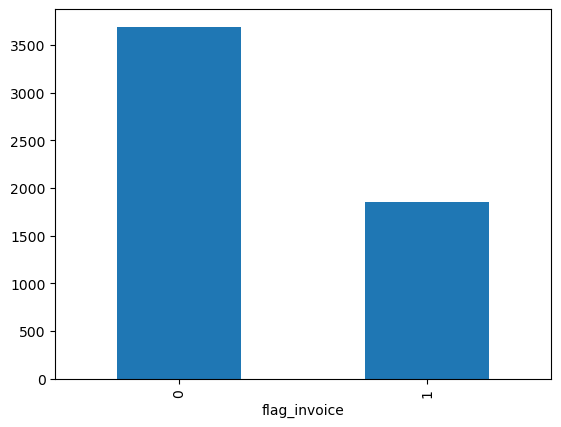

In [15]:
gh['flag_invoice'].value_counts().plot(kind='bar')

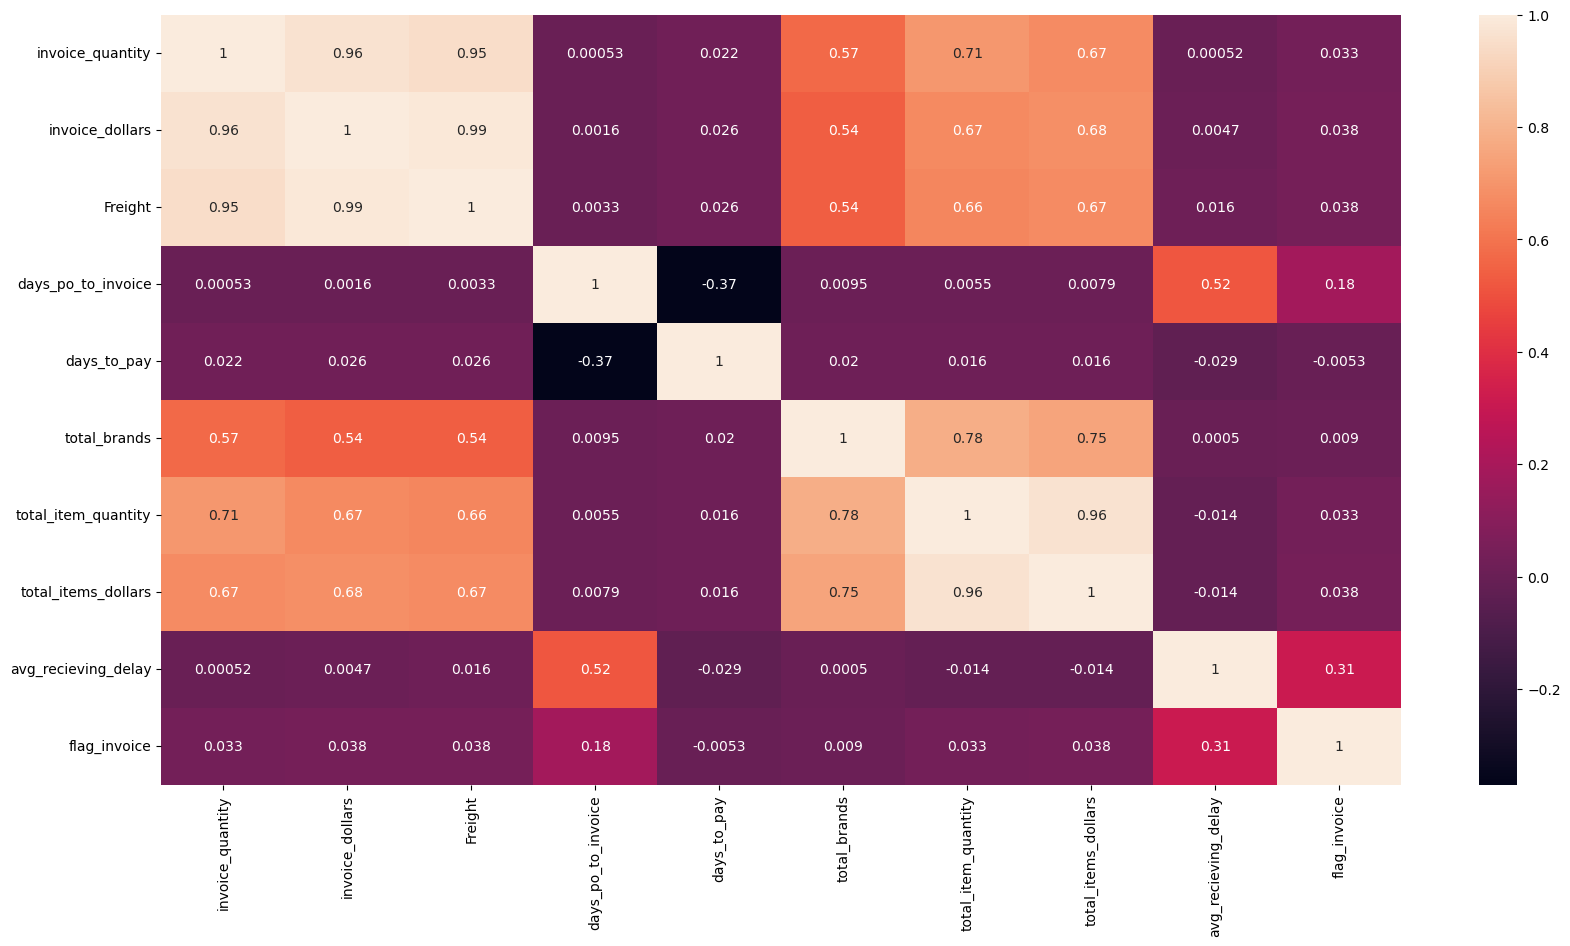

In [16]:
plt.figure(figsize=(20,10))
sns.heatmap(gh.iloc[:,1:].corr(),annot=True)
plt.show()

In [17]:
flagged=gh[gh['flag_invoice']==1]
normal=gh[gh['flag_invoice']==0]

In [18]:
significant_features=[]
non_significant_features=[]
results=[]

In [19]:
metrics=['invoice_quantity','invoice_dollars','Freight',
       'days_po_to_invoice','days_to_pay','total_brands',
    'total_item_quantity','total_items_dollars','avg_recieving_delay']

In [20]:
from scipy.stats import ttest_ind
for metric in metrics:
    flagged_mean=flagged[metric].mean()
    normal_mean=normal[metric].mean()
    
    t_stat,p_value=ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )
    if p_value<0.05:
        significant_features.append(metric)
        results.append({
            "metric":metric,
            "flagged_mean":flagged_mean.round(2),
            "normal_mean":normal_mean.round(2),
            "p_value": p_value.round(3)
        })
        
    else:
        non_significant_features.append(metric)

In [21]:
non_significant_features

['days_to_pay', 'total_brands']

In [22]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_items_dollars',
 'avg_recieving_delay']

In [23]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'invoice_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'Freight',
  'flagged_mean': 334.02,
  'normal_mean': 276.89,
  'p_value': 0.008},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': 17.23,
  'normal_mean': 16.02,
  'p_value': 0.0},
 {'metric': 'total_item_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'total_items_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'avg_recieving_delay',
  'flagged_mean': 8.47,
  'normal_mean': 7.27,
  'p_value': 0.0}]

In [24]:
gh.describe().round()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_items_dollars,avg_recieving_delay,flag_invoice
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,10889.0,6059.0,58073.0,296.0,16.0,35.0,41.0,6059.0,58073.0,8.0,0.0
std,1601.0,14453.0,140234.0,714.0,3.0,6.0,77.0,14453.0,140234.0,2.0,0.0
min,8106.0,1.0,4.0,0.0,9.0,23.0,1.0,1.0,4.0,3.0,0.0
25%,9504.0,83.0,968.0,5.0,14.0,31.0,3.0,83.0,968.0,6.0,0.0
50%,10890.0,423.0,4765.0,25.0,16.0,35.0,7.0,423.0,4765.0,8.0,0.0
75%,12276.0,5100.0,44587.0,230.0,19.0,40.0,46.0,5100.0,44587.0,9.0,1.0
max,13661.0,141660.0,1660436.0,8468.0,23.0,48.0,807.0,141660.0,1660436.0,13.0,1.0


In [25]:
#Input Parameter
X=gh[['invoice_quantity','invoice_dollars','Freight','days_po_to_invoice','total_item_quantity','total_items_dollars','avg_recieving_delay']]
#Output
y=gh['flag_invoice']

In [26]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_item_quantity,total_items_dollars,avg_recieving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,6059.0,58073.0,8.0
std,14453.0,140234.0,714.0,3.0,14453.0,140234.0,2.0
min,1.0,4.0,0.0,9.0,1.0,4.0,3.0
25%,83.0,968.0,5.0,14.0,83.0,968.0,6.0
50%,423.0,4765.0,25.0,16.0,423.0,4765.0,8.0
75%,5100.0,44587.0,230.0,19.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,23.0,141660.0,1660436.0,13.0


In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)


In [38]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler=MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [40]:
model1=LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [41]:
model2=DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [42]:
model3=RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [43]:
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

def evaluate_model(model, X_test_scaled, y_test, target_names=None, proba=True):
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if proba else None

    sep = "=" * 50

    # ── Accuracy ──────────────────────────────────────
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{sep}")
    print(f"  ACCURACY : {acc:.4f}")
    print(sep)

    # ── Per-class metrics ─────────────────────────────
    print("\n  CLASSIFICATION REPORT")
    print(sep)
    print(classification_report(y_test, y_pred, target_names=target_names))

    # ── Macro & Weighted averages ─────────────────────
    for avg in ["macro", "weighted"]:
        p  = precision_score(y_test, y_pred, average=avg)
        r  = recall_score   (y_test, y_pred, average=avg)
        f1 = f1_score       (y_test, y_pred, average=avg)
        print(f"  {avg.upper():>8} AVG →  P: {p:.4f}  R: {r:.4f}  F1: {f1:.4f}")

    # ── AUC ──────────────────────────────────────────
    if proba:
        auc = roc_auc_score(y_test, y_proba)
        print(f"\n  ROC-AUC  : {auc:.4f}")
    print(f"{sep}\n")

    # ── Confusion Matrix plot ─────────────────────────
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=target_names,
        cmap="Blues"
    )
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()


  ACCURACY : 0.7502

  CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.74      0.95      0.83       725
         Yes       0.81      0.37      0.50       384

    accuracy                           0.75      1109
   macro avg       0.77      0.66      0.67      1109
weighted avg       0.76      0.75      0.72      1109

     MACRO AVG →  P: 0.7728  R: 0.6601  F1: 0.6688
  WEIGHTED AVG →  P: 0.7626  R: 0.7502  F1: 0.7193

  ROC-AUC  : 0.6591



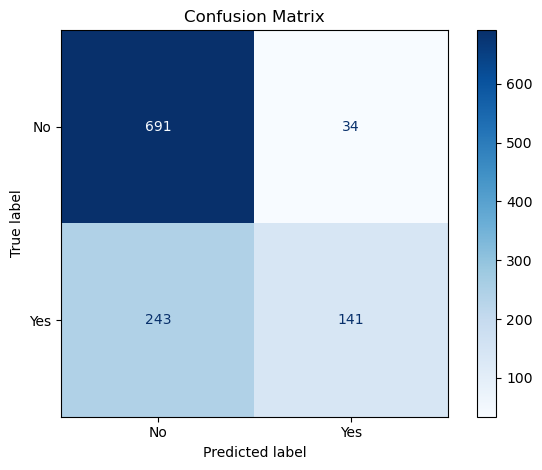

In [44]:
evaluate_model(
    model1,
    X_test_scaled,
    y_test,
    target_names=["No", "Yes"],
    proba=True
)


  ACCURACY : 0.9252

  CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.93      0.95      0.94       725
         Yes       0.91      0.87      0.89       384

    accuracy                           0.93      1109
   macro avg       0.92      0.91      0.92      1109
weighted avg       0.92      0.93      0.92      1109

     MACRO AVG →  P: 0.9213  R: 0.9121  F1: 0.9165
  WEIGHTED AVG →  P: 0.9248  R: 0.9252  F1: 0.9247

  ROC-AUC  : 0.9121



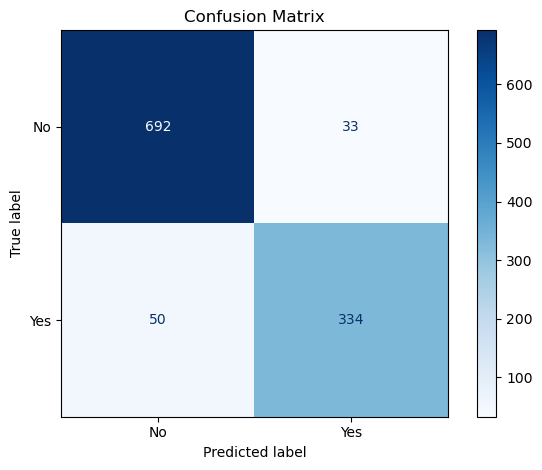

In [45]:
evaluate_model(
    model2,
    X_test_scaled,
    y_test,
    target_names=["No", "Yes"],
    proba=True
)


  ACCURACY : 0.9504

  CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.93      1.00      0.96       725
         Yes       1.00      0.86      0.92       384

    accuracy                           0.95      1109
   macro avg       0.96      0.93      0.94      1109
weighted avg       0.95      0.95      0.95      1109

     MACRO AVG →  P: 0.9647  R: 0.9284  F1: 0.9432
  WEIGHTED AVG →  P: 0.9539  R: 0.9504  F1: 0.9494

  ROC-AUC  : 0.9859



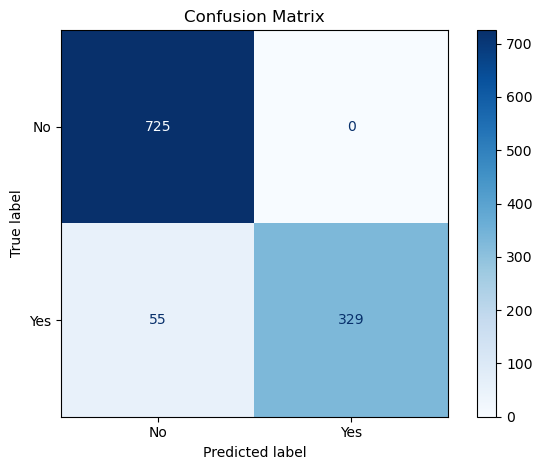

In [46]:
evaluate_model(
    model3,
    X_test_scaled,
    y_test,
    target_names=["No", "Yes"],
    proba=True
)

# Here we got the best results using MinMaxScaler() where Accuracy of Model 3 "Random Forest Classifer is highest"

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.5s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.4s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; tot

C:\Users\piyus\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



  ACCURACY : 0.9504

  CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.93      1.00      0.96       725
         Yes       1.00      0.86      0.92       384

    accuracy                           0.95      1109
   macro avg       0.96      0.93      0.94      1109
weighted avg       0.95      0.95      0.95      1109

     MACRO AVG →  P: 0.9647  R: 0.9284  F1: 0.9432
  WEIGHTED AVG →  P: 0.9539  R: 0.9504  F1: 0.9494

  ROC-AUC  : 0.9889



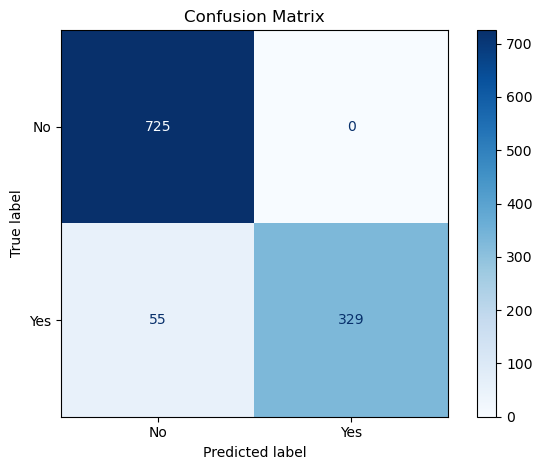

In [47]:
# HyperParamter Tuning Using Grid Search CV
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf=RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid={
    "n_estimators": [100,200,300],
    "max_depth": [None,4,5,6],
    "min_samples_split": [2,3,5],
    "min_samples_leaf": [1,2,5],
    "criterion":['gini','entropy']}

scorer=make_scorer(f1_score)
grid_search=GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=1

)

grid_search.fit(X_train_scaled,y_train)
# evaluate_model(grid_search,X_test_scaled,y_test,'Random Forest Classifier')
evaluate_model(
    grid_search,
    X_test_scaled,
    y_test,
    target_names=["No", "Yes"],
    proba=True
)

## We tried Hyper Parameter tung but results are similar

In [49]:
# This will tell us parameters for our model whcih gives best parameters
best_Parameters=grid_search.best_params_

In [50]:
best_Parameters

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 3,
 'n_estimators': 200}